# xsynth — Progressive Demo

This notebook demonstrates progressively more complex examples of using `xsynth`:
1) basic device ops, 2) single-device scan, 3) multi-device scan, 4) inspect and save results.
Run cells in order; examples default to `write=False` so they're safe to run without hardware.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from xsynth.main import Scan, SetDevice, SetADAPTMLS
from xsynth.device import ADAPTX, IBFB_X, IBFB_Y
from xsynth.plot import plot_scan_summary
print('imports OK')

imports OK


## Example 1 — Basic device set (dry-run)
Safely change device settings using `SetDevice` with `write=False`.

In [2]:
# dry-run: update ADAPTX value without sending to hardware
SetDevice(ADAPTX, value=0.5, beam_region='SA1', write=False)
# show key attributes for inspection
{k: getattr(ADAPTX, k) for k in ['name','channel','range'] if hasattr(ADAPTX, k)}

# Scan Points: 1


100%|██████████| 1/1 [00:00<00:00, 3823.43it/s]


{}

## Example 2 — Single-device scan
Sweep one device variable using built-in oscillator types. This example uses `write=False` so it won't change hardware.

# Scan Points: 11


100%|██████████| 11/11 [00:00<00:00, 48.94it/s]


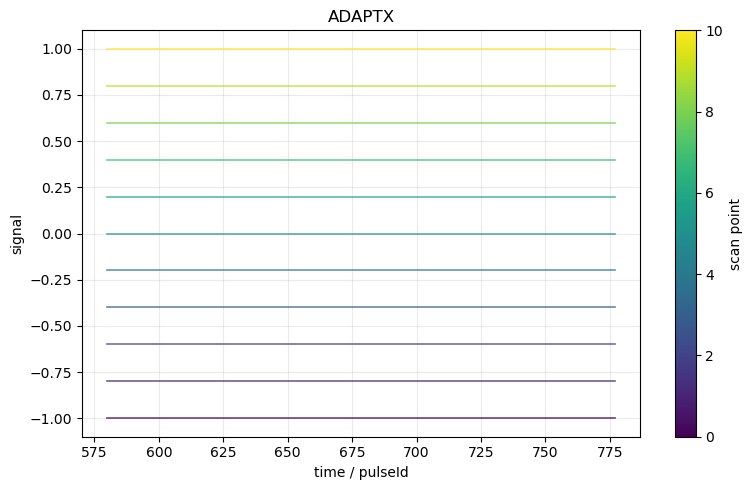

In [8]:
scan1 = Scan(
    devices=[ADAPTX],
    scan_vectors=[np.linspace(-1.0, 1.0, 11)],
    beam_region='SA1',
    oscillators=['line'],
    oscillator_variables=[{'V2': 0.0}],
    scan_variables=['V2'],
    wait_time=0.02,
    write=False,
    all_messages=True,
    display=False,
)
# plot a quick summary (returns a Matplotlib figure)
fig1, ax1 = plot_scan_summary(scan1)


## Example 3 — Multi-device, multi-signal scan
Run a scan over two devices with different oscillators and inspect the results.

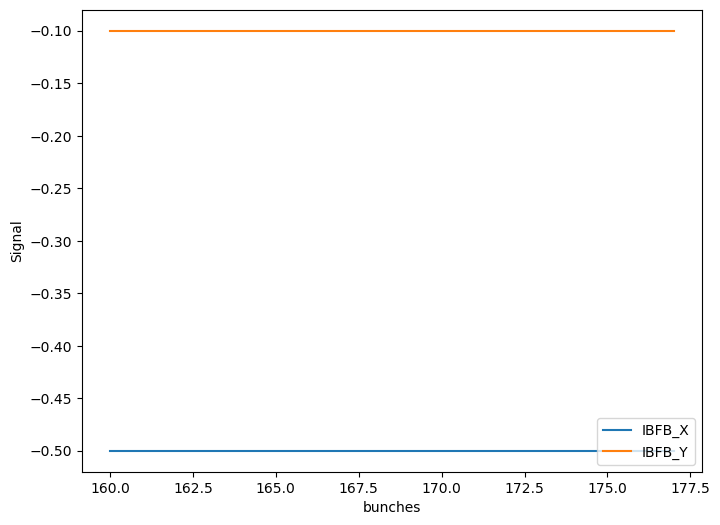

 26%|██▌       | 115/441 [00:15<00:58,  5.59it/s]

In [ ]:
scan2 = Scan(
    devices=[IBFB_X, IBFB_Y],
    scan_vectors=[np.linspace(-1.0, 1.0, 21), np.linspace(-1.0, 1.0, 21)],
    beam_region='SA2',
    oscillators=['line', 'line'],
    oscillator_variables=[{'V2': 0.0}, {'V2': 0.0}],
    scan_variables=['V2','V2'],
    wait_time=0.02,
    write=True,
    all_messages=True,
    display=True,
)
# show a compact summary and internal structure
scan2.plot_summary()

## Example 4 — Inspecting & saving results
Access collected signals and optionally save results to disk.

---
Notes:
- Keep `write=False` unless you're connected to the correct hardware and ready to change settings.
- To expand this notebook I can add: custom signal/device classes, live plotting hooks, or example data imports/exports.
- Tell me which devices or signal behaviors you'd like demonstrated next.